# Caesar Prime Comparison Analyzer

This notebook analyzes results from the Caesar cipher comparison experiments:
- **Alphabet 26**: Standard a-z (676 experiments)
- **Alphabet 29**: Extended a-z + !?£ (841 experiments)

All experiments use `noise_std=0` (clean data) with fixed hyperparameters.

**Key Question**: Does the prime alphabet size (29) affect infusion targeting compared to composite (26 = 2 × 13)?

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch
from pathlib import Path
from tqdm import tqdm
from scipy import stats
import math

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Configure plot aesthetics for paper
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Results directory
RESULTS_DIR = Path('/scratch/s5e/jrosser.s5e/infusion/caesar_prime/results')

print(f"Results directory: {RESULTS_DIR}")
print(f"Exists: {RESULTS_DIR.exists()}")

Results directory: /scratch/s5e/jrosser.s5e/infusion/caesar_prime/results
Exists: True


## 1. Load Results from Disk

Load all completed experiments from the results directory.

In [2]:
def load_all_results(results_dir: Path) -> pd.DataFrame:
    """Load all experiment results from disk."""
    all_results = []
    
    for alph_dir in sorted(results_dir.glob('alph_*')):
        alphabet_size = int(alph_dir.name.split('_')[1])
        
        for exp_dir in sorted(alph_dir.glob('p*_t*')):
            metrics_file = exp_dir / 'metrics.json'
            config_file = exp_dir / 'config.json'
            
            if not metrics_file.exists():
                continue
                
            try:
                with open(metrics_file) as f:
                    metrics = json.load(f)
                with open(config_file) as f:
                    config = json.load(f)
                
                # Combine metrics and config
                result = {**metrics, **config}
                result['exp_dir'] = str(exp_dir)
                all_results.append(result)
            except Exception as e:
                print(f"Error loading {exp_dir}: {e}")
    
    return pd.DataFrame(all_results)

# Load results
df = load_all_results(RESULTS_DIR)
print(f"Loaded {len(df)} experiments")

# Summary by alphabet size
if len(df) > 0:
    print("\nExperiments by alphabet size:")
    print(df.groupby('alphabet_size').size())

Loaded 1517 experiments

Experiments by alphabet size:
alphabet_size
26    676
29    841
dtype: int64


In [3]:
# Alternative: Load from wandb if disk results not available
def load_from_wandb(project="caesar-prime-compare", entity="jrosseruk"):
    """Load results from wandb."""
    api = wandb.Api()
    runs = api.runs(f"{entity}/{project}")
    
    all_data = []
    for run in tqdm(runs, desc="Loading wandb runs"):
        if run.state in ['finished', 'running']:
            try:
                history = run.history()
                if len(history) > 0:
                    # Get last logged values
                    last = history.iloc[-1].to_dict()
                    last['run_id'] = run.id
                    last['run_name'] = run.name
                    last['state'] = run.state
                    all_data.append(last)
            except:
                pass
    
    return pd.DataFrame(all_data)

# Uncomment to load from wandb instead
# df = load_from_wandb()
# print(f"Loaded {len(df)} experiments from wandb")

## 2. Experiment Progress

In [4]:
# Check completion status
total_26 = 26 * 26  # 676
total_29 = 29 * 29  # 841
total_expected = total_26 + total_29  # 1517

if len(df) > 0:
    completed_26 = len(df[df['alphabet_size'] == 26])
    completed_29 = len(df[df['alphabet_size'] == 29])
else:
    completed_26 = 0
    completed_29 = 0

print("="*50)
print("EXPERIMENT PROGRESS")
print("="*50)
print(f"\nAlphabet 26 (a-z):     {completed_26:4d} / {total_26} ({100*completed_26/total_26:.1f}%)")
print(f"Alphabet 29 (a-z+!?£): {completed_29:4d} / {total_29} ({100*completed_29/total_29:.1f}%)")
print(f"{'─'*50}")
print(f"Total:                 {completed_26 + completed_29:4d} / {total_expected} ({100*(completed_26+completed_29)/total_expected:.1f}%)")

EXPERIMENT PROGRESS

Alphabet 26 (a-z):      676 / 676 (100.0%)
Alphabet 29 (a-z+!?£):  841 / 841 (100.0%)
──────────────────────────────────────────────────
Total:                 1517 / 1517 (100.0%)


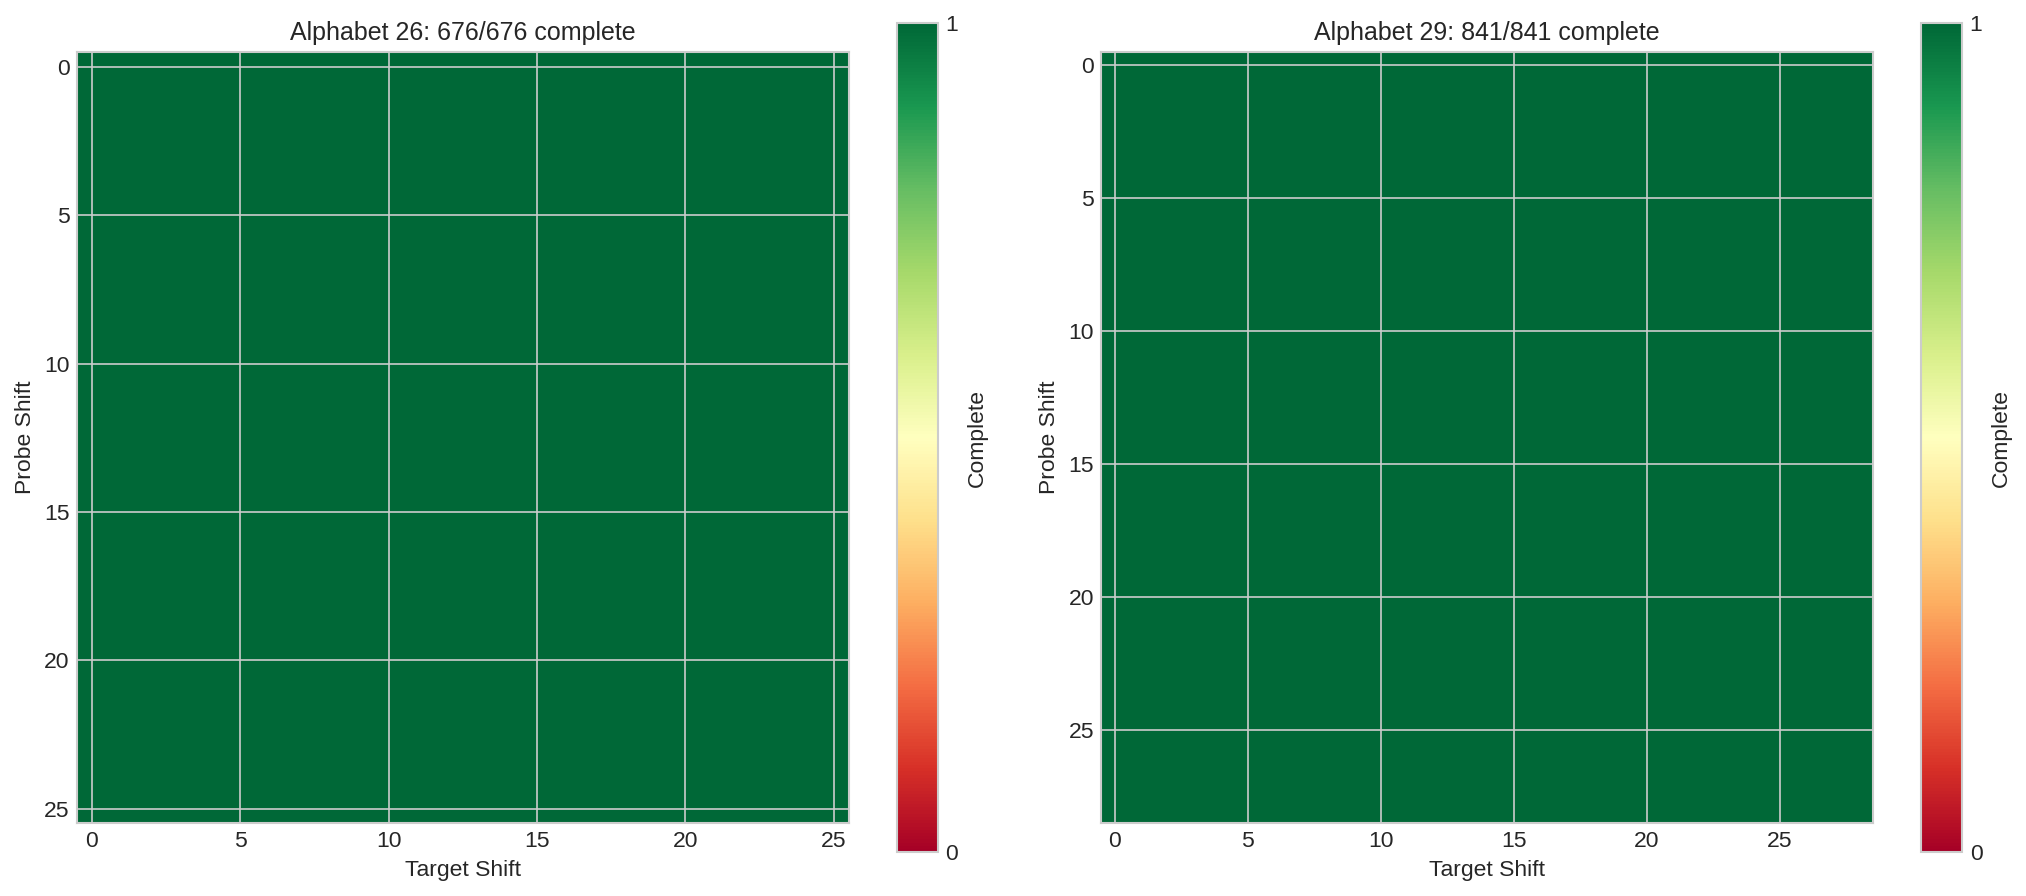

In [5]:
# Visualize completion status with heatmaps
if len(df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, alph_size in zip(axes, [26, 29]):
        # Create completion matrix
        completion = np.zeros((alph_size, alph_size))
        df_alph = df[df['alphabet_size'] == alph_size]
        
        for _, row in df_alph.iterrows():
            p, t = int(row['probe_shift']), int(row['target_shift'])
            completion[p, t] = 1
        
        # Plot
        im = ax.imshow(completion, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
        ax.set_xlabel('Target Shift')
        ax.set_ylabel('Probe Shift')
        ax.set_title(f'Alphabet {alph_size}: {int(completion.sum())}/{alph_size**2} complete')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, label='Complete', ticks=[0, 1])
    
    plt.tight_layout()
    plt.savefig('figures/completion_status.png', bbox_inches='tight')
    plt.show()
else:
    print("No data to visualize yet.")

## 3. Summary Statistics

In [6]:
if len(df) > 0 and 'targeting_score' in df.columns:
    print("="*60)
    print("TARGETING SCORE STATISTICS BY ALPHABET SIZE")
    print("="*60)
    
    for alph_size in [26, 29]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            print(f"\nAlphabet {alph_size}:")
            print(df_alph['targeting_score'].describe())
            print(f"Positive targeting: {(df_alph['targeting_score'] > 0).sum()} / {len(df_alph)} ({100*(df_alph['targeting_score'] > 0).mean():.1f}%)")
else:
    print("No targeting score data available yet.")

TARGETING SCORE STATISTICS BY ALPHABET SIZE

Alphabet 26:
count    676.000000
mean       1.339255
std        0.985008
min       -0.578502
25%        0.417490
50%        1.176528
75%        2.277824
max        3.392593
Name: targeting_score, dtype: float64
Positive targeting: 645 / 676 (95.4%)

Alphabet 29:
count    841.000000
mean       1.006093
std        0.724276
min       -0.147776
25%        0.371669
50%        0.857507
75%        1.612353
max        2.831432
Name: targeting_score, dtype: float64
Positive targeting: 813 / 841 (96.7%)


In [7]:
# Best and worst experiments
if len(df) > 0 and 'targeting_score' in df.columns:
    print("\nTop 10 Experiments by Targeting Score:")
    top_cols = ['alphabet_size', 'probe_shift', 'target_shift', 'targeting_score', 
                'delta_ce_target', 'delta_ce_other']
    display_cols = [c for c in top_cols if c in df.columns]
    print(df.nlargest(10, 'targeting_score')[display_cols].to_string())
    
    print("\n\nBottom 10 Experiments by Targeting Score:")
    print(df.nsmallest(10, 'targeting_score')[display_cols].to_string())


Top 10 Experiments by Targeting Score:
     alphabet_size  probe_shift  target_shift  targeting_score  delta_ce_target  delta_ce_other
182             26           16             0         3.392593        -4.277564       -0.884971
202             26           16             4         3.297784        -4.167607       -0.869823
194             26           16             2         3.284342        -4.097347       -0.813004
666             26            9            23         3.205971        -4.263553       -1.057583
263             26           19            11         3.183133        -4.536731       -1.353598
125             26           13             5         3.182940        -3.970797       -0.787857
334             26           20             6         3.176448        -4.309808       -1.133360
669             26            9             3         3.101369        -3.356447       -0.255077
384             26           22             4         3.093746        -3.807930       -0.714184


## 4. Targeting Score Distribution Comparison

Compare targeting score distributions between alphabet sizes.

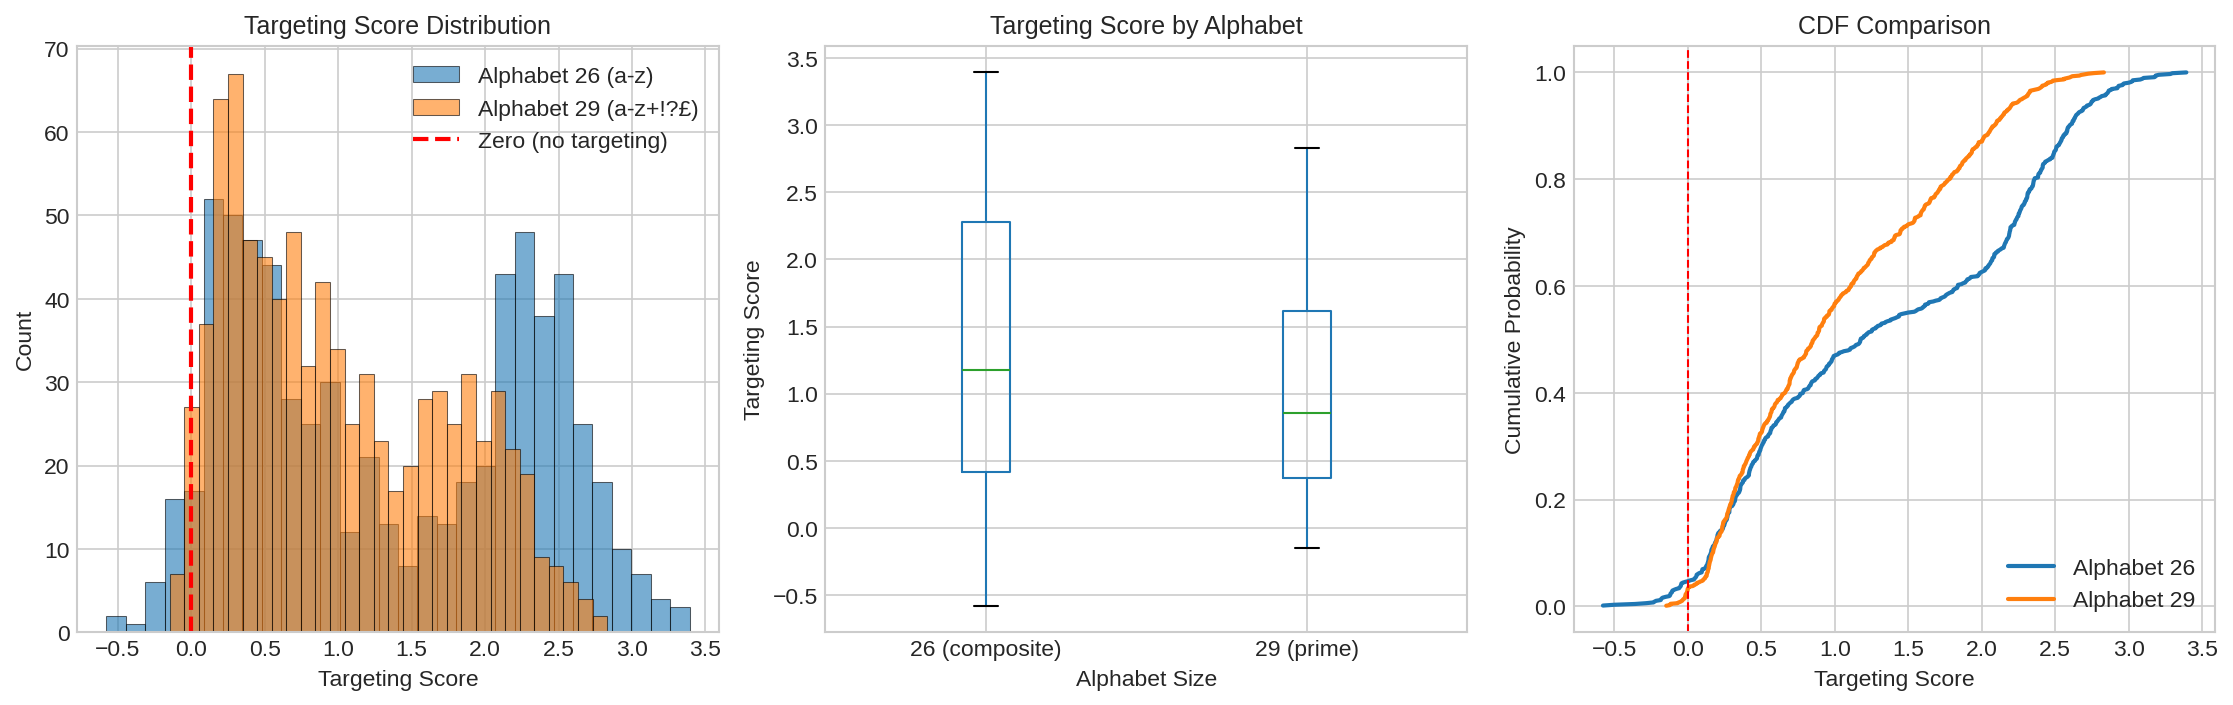

In [8]:
if len(df) > 0 and 'targeting_score' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Separate histograms
    ax = axes[0]
    for alph_size, color, label in [(26, 'C0', 'Alphabet 26 (a-z)'), 
                                     (29, 'C1', 'Alphabet 29 (a-z+!?£)')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            ax.hist(df_alph['targeting_score'], bins=30, alpha=0.6, 
                    label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (no targeting)')
    ax.set_xlabel('Targeting Score')
    ax.set_ylabel('Count')
    ax.set_title('Targeting Score Distribution')
    ax.legend()
    
    # Box plot comparison
    ax = axes[1]
    df_plot = df[df['alphabet_size'].isin([26, 29])].copy()
    df_plot['alphabet_label'] = df_plot['alphabet_size'].map({26: '26 (composite)', 29: '29 (prime)'})
    df_plot.boxplot(column='targeting_score', by='alphabet_label', ax=ax)
    ax.set_xlabel('Alphabet Size')
    ax.set_ylabel('Targeting Score')
    ax.set_title('Targeting Score by Alphabet')
    plt.suptitle('')  # Remove automatic title
    
    # CDF comparison
    ax = axes[2]
    for alph_size, color, label in [(26, 'C0', 'Alphabet 26'), (29, 'C1', 'Alphabet 29')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            sorted_scores = np.sort(df_alph['targeting_score'])
            cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
            ax.plot(sorted_scores, cdf, label=label, color=color, linewidth=2)
    
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Targeting Score')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title('CDF Comparison')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('figures/targeting_score_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print("Insufficient data for plotting.")

## 5. Targeting Score Heatmaps

Visualize targeting success across all (probe_shift, target_shift) combinations.

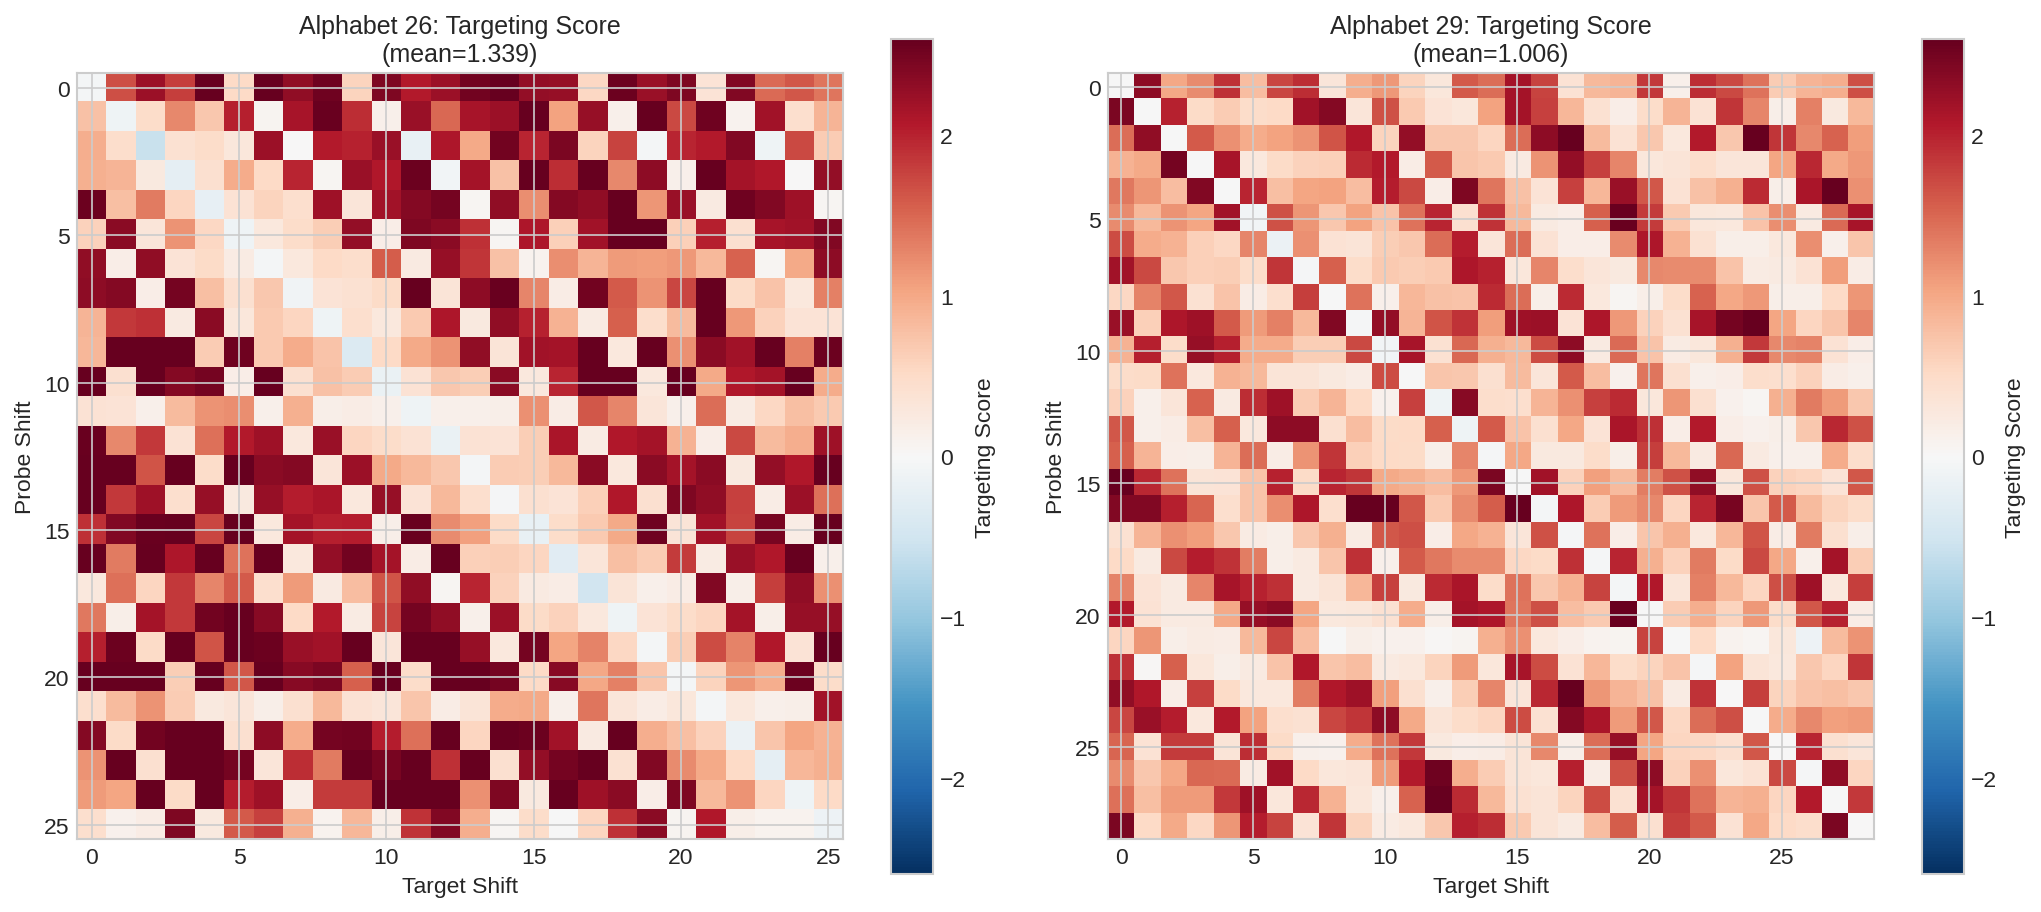

In [9]:
if len(df) > 0 and 'targeting_score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Get common color scale
    vmin = df['targeting_score'].quantile(0.05)
    vmax = df['targeting_score'].quantile(0.95)
    vabs = max(abs(vmin), abs(vmax))
    
    for ax, alph_size in zip(axes, [26, 29]):
        df_alph = df[df['alphabet_size'] == alph_size]
        
        if len(df_alph) > 0:
            # Create heatmap matrix
            heatmap = np.full((alph_size, alph_size), np.nan)
            for _, row in df_alph.iterrows():
                p, t = int(row['probe_shift']), int(row['target_shift'])
                heatmap[p, t] = row['targeting_score']
            
            # Plot
            im = ax.imshow(heatmap, cmap='RdBu_r', vmin=-vabs, vmax=vabs, aspect='equal')
            ax.set_xlabel('Target Shift')
            ax.set_ylabel('Probe Shift')
            ax.set_title(f'Alphabet {alph_size}: Targeting Score\n(mean={df_alph["targeting_score"].mean():.3f})')
            plt.colorbar(im, ax=ax, label='Targeting Score')
        else:
            ax.set_title(f'Alphabet {alph_size}: No data')
    
    plt.tight_layout()
    plt.savefig('figures/targeting_heatmaps.png', bbox_inches='tight')
    plt.show()
else:
    print("Insufficient data for heatmaps.")

## 6. Shift Difference Analysis

Analyze how targeting success varies with the distance between probe and target shifts.

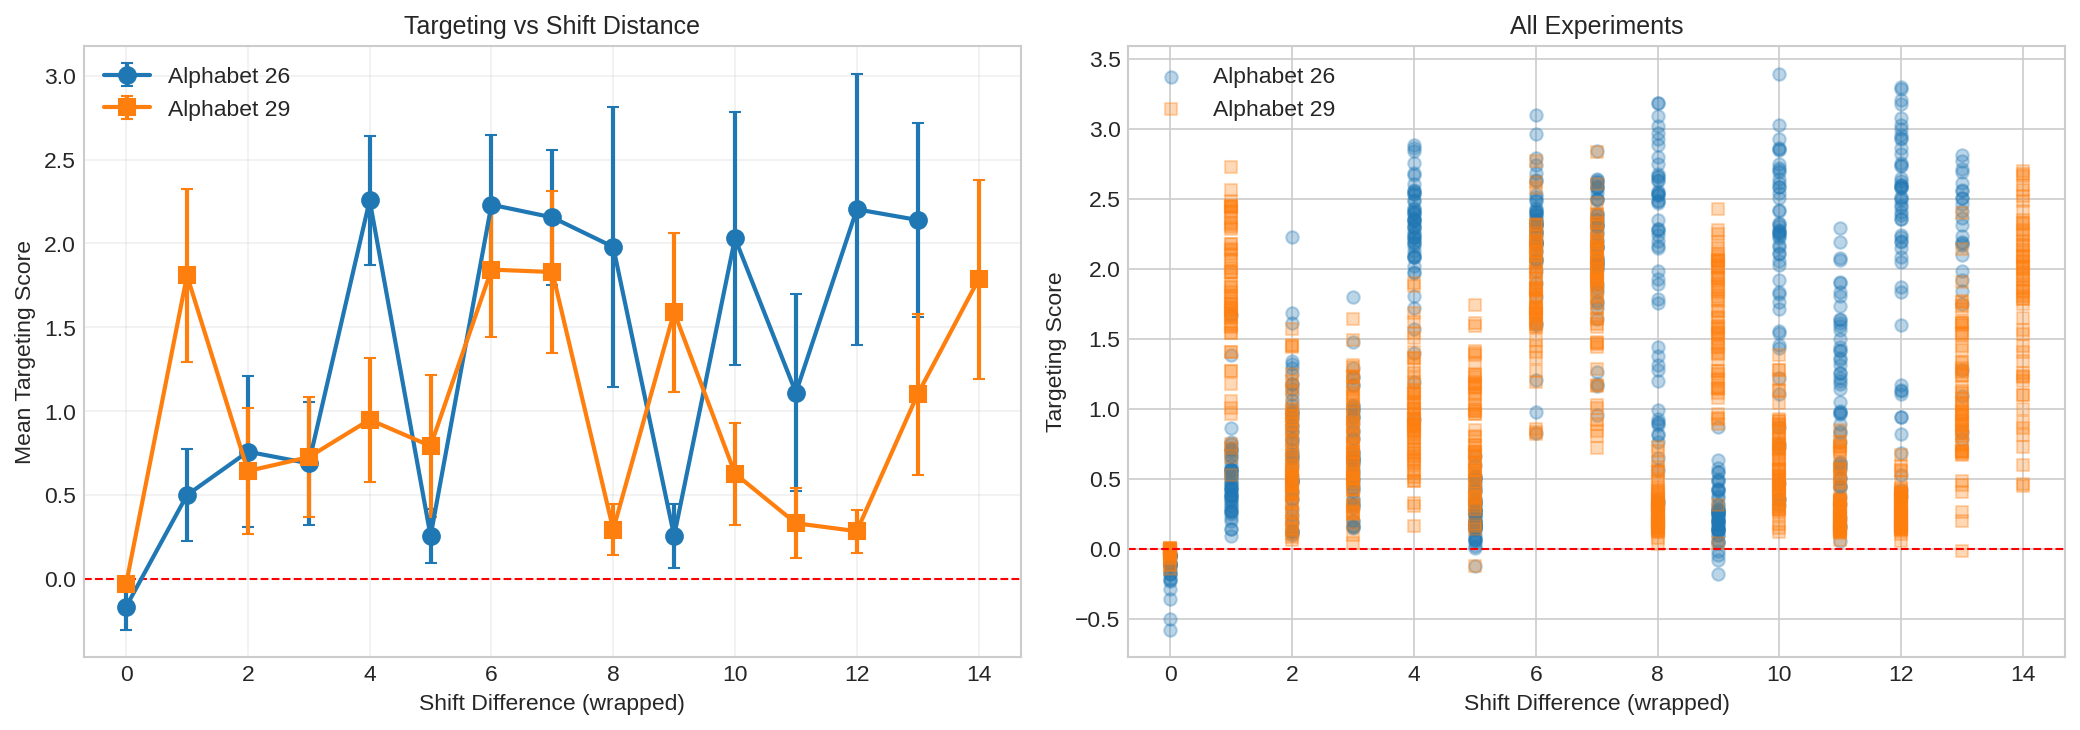

In [10]:
if len(df) > 0 and 'targeting_score' in df.columns:
    # Compute shift difference (wrapped to half-alphabet)
    df['shift_diff_raw'] = (df['target_shift'] - df['probe_shift']).abs()
    df['shift_diff_wrapped'] = df.apply(
        lambda row: min(row['shift_diff_raw'], row['alphabet_size'] - row['shift_diff_raw']), 
        axis=1
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Targeting vs shift difference
    ax = axes[0]
    for alph_size, color, marker in [(26, 'C0', 'o'), (29, 'C1', 's')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            means = df_alph.groupby('shift_diff_wrapped')['targeting_score'].mean()
            stds = df_alph.groupby('shift_diff_wrapped')['targeting_score'].std()
            ax.errorbar(means.index, means.values, yerr=stds.values, 
                       marker=marker, color=color, label=f'Alphabet {alph_size}',
                       capsize=3, linewidth=2, markersize=8)
    
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Shift Difference (wrapped)')
    ax.set_ylabel('Mean Targeting Score')
    ax.set_title('Targeting vs Shift Distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Scatter plot
    ax = axes[1]
    for alph_size, color, marker in [(26, 'C0', 'o'), (29, 'C1', 's')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            ax.scatter(df_alph['shift_diff_wrapped'], df_alph['targeting_score'],
                      alpha=0.3, color=color, marker=marker, label=f'Alphabet {alph_size}')
    
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Shift Difference (wrapped)')
    ax.set_ylabel('Targeting Score')
    ax.set_title('All Experiments')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('figures/shift_difference_analysis.png', bbox_inches='tight')
    plt.show()

## 7. Fourier/GCD Analysis

Test whether shifts sharing factors with the alphabet size are harder to attack.

- **Alphabet 26** = 2 × 13 (composite): shifts with GCD > 1 may be problematic
- **Alphabet 29** (prime): all shifts coprime, no special structure

In [11]:
def factorize(n):
    """Return prime factors of n."""
    factors = []
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors.append(d)
            n //= d
        d += 1
    if n > 1:
        factors.append(n)
    return factors if factors else [n]

if len(df) > 0 and 'targeting_score' in df.columns:
    # Compute GCD with alphabet size
    df['gcd_with_alph'] = df.apply(
        lambda row: math.gcd(int(row['shift_diff_wrapped']), int(row['alphabet_size'])),
        axis=1
    )
    df['is_coprime'] = df['gcd_with_alph'] == 1
    
    print("="*60)
    print("GCD ANALYSIS")
    print("="*60)
    
    for alph_size in [26, 29]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            print(f"\nAlphabet {alph_size}:")
            print(f"  Factors: {alph_size} = {' × '.join(str(f) for f in factorize(alph_size))}")
            print(f"  GCD distribution:")
            for gcd_val in sorted(df_alph['gcd_with_alph'].unique()):
                df_gcd = df_alph[df_alph['gcd_with_alph'] == gcd_val]
                print(f"    GCD={gcd_val}: n={len(df_gcd)}, mean_targeting={df_gcd['targeting_score'].mean():.4f}")

GCD ANALYSIS

Alphabet 26:
  Factors: 26 = 2 × 13
  GCD distribution:
    GCD=1: n=312, mean_targeting=0.8273
    GCD=2: n=312, mean_targeting=1.9100
    GCD=13: n=26, mean_targeting=2.1398
    GCD=26: n=26, mean_targeting=-0.1665

Alphabet 29:
  Factors: 29 = 29
  GCD distribution:
    GCD=1: n=812, mean_targeting=1.0431
    GCD=29: n=29, mean_targeting=-0.0309


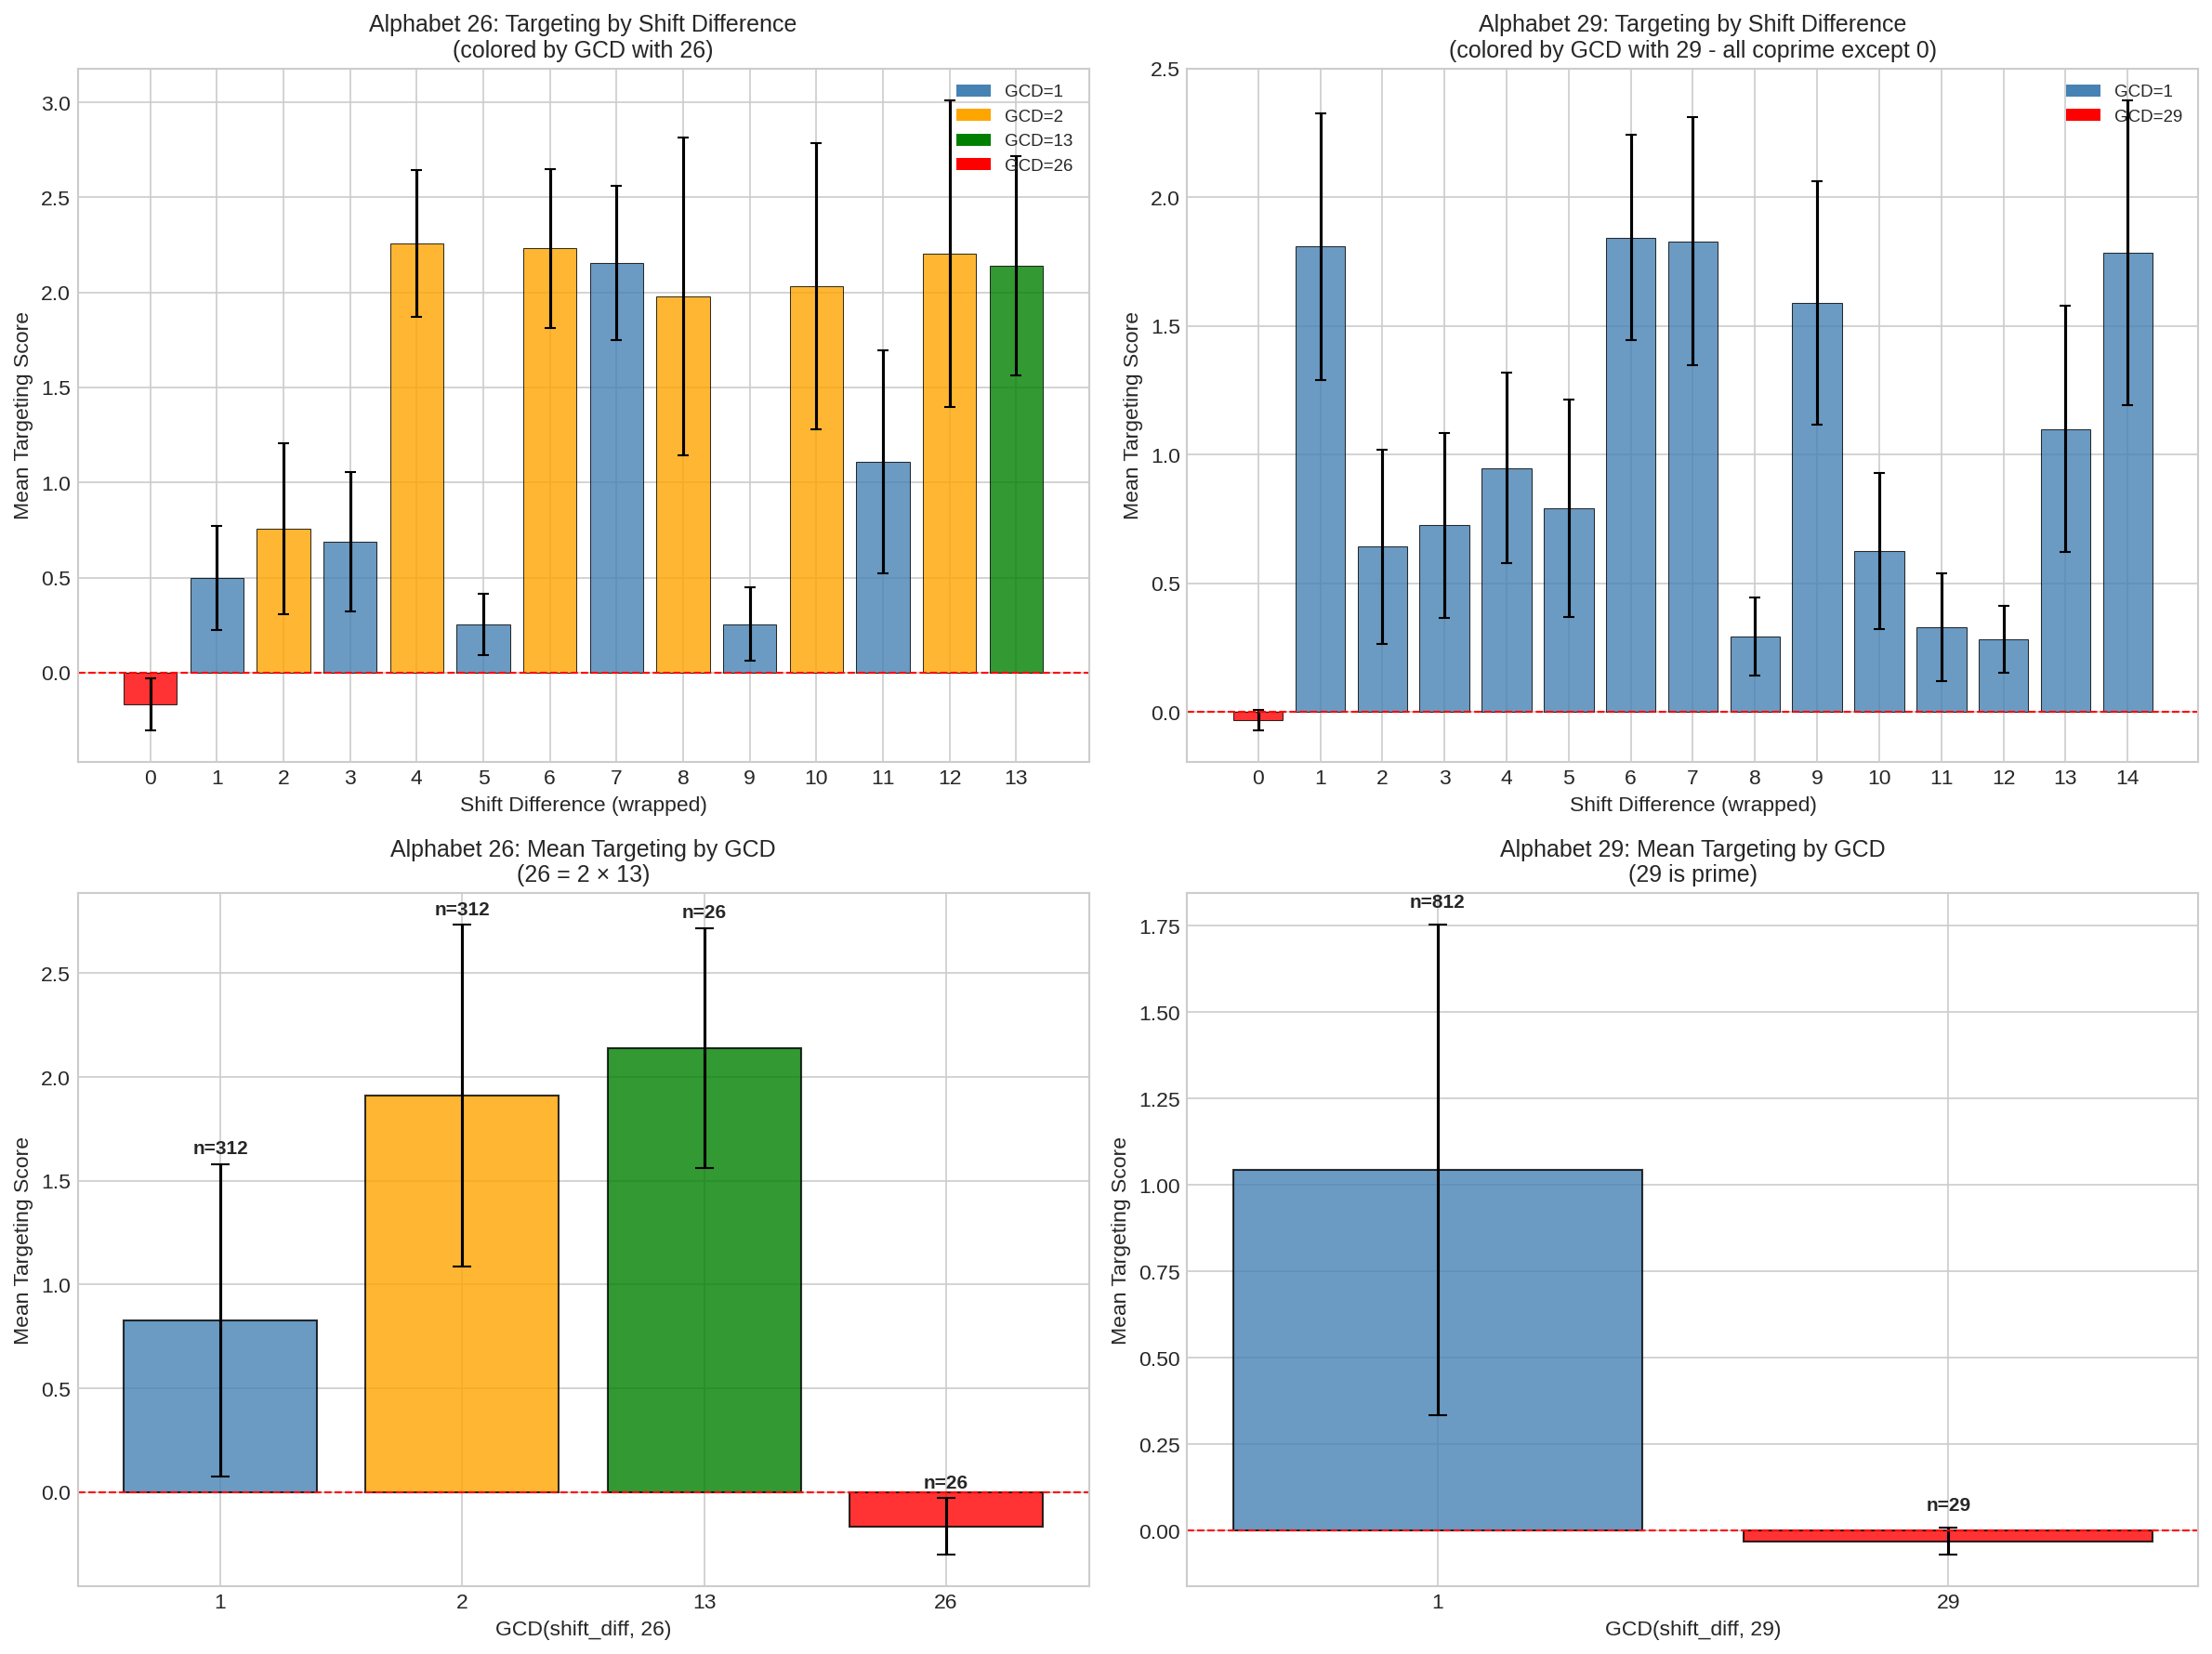


GCD ANALYSIS SUMMARY

Alphabet 26 (26 = 2 × 13):
  GCD= 1: mean=0.827 ± 0.753 (n=312)
  GCD= 2: mean=1.910 ± 0.823 (n=312)
  GCD=13: mean=2.140 ± 0.577 (n=26)
  GCD=26: mean=-0.167 ± 0.137 (n=26)

Alphabet 29 (prime):
  GCD= 1: mean=1.043 ± 0.710 (n=812)
  GCD=29: mean=-0.031 ± 0.039 (n=29)


In [12]:
if len(df) > 0 and 'targeting_score' in df.columns and 'gcd_with_alph' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Color maps for GCD values
    gcd_colors_26 = {1: 'steelblue', 2: 'orange', 13: 'green', 26: 'red'}
    gcd_colors_29 = {1: 'steelblue', 29: 'red'}  # 29 is prime, only GCD=1 or 29
    
    # ===== TOP ROW: Bar plots by shift difference with GCD coloring =====
    
    # Alphabet 26
    ax = axes[0, 0]
    df_26 = df[df['alphabet_size'] == 26]
    if len(df_26) > 0:
        shift_means = df_26.groupby('shift_diff_wrapped')['targeting_score'].mean()
        shift_stds = df_26.groupby('shift_diff_wrapped')['targeting_score'].std()
        
        # Get GCD for each shift difference
        shifts = shift_means.index.values
        colors = [gcd_colors_26.get(math.gcd(int(s), 26), 'gray') for s in shifts]
        
        bars = ax.bar(shifts, shift_means.values, yerr=shift_stds.values, 
                     capsize=3, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('Shift Difference (wrapped)')
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title('Alphabet 26: Targeting by Shift Difference\n(colored by GCD with 26)')
        ax.set_xticks(shifts)
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=c, label=f'GCD={g}') 
                          for g, c in sorted(gcd_colors_26.items())]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    # Alphabet 29
    ax = axes[0, 1]
    df_29 = df[df['alphabet_size'] == 29]
    if len(df_29) > 0:
        shift_means = df_29.groupby('shift_diff_wrapped')['targeting_score'].mean()
        shift_stds = df_29.groupby('shift_diff_wrapped')['targeting_score'].std()
        
        shifts = shift_means.index.values
        colors = [gcd_colors_29.get(math.gcd(int(s), 29), 'steelblue') for s in shifts]
        
        bars = ax.bar(shifts, shift_means.values, yerr=shift_stds.values,
                     capsize=3, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('Shift Difference (wrapped)')
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title('Alphabet 29: Targeting by Shift Difference\n(colored by GCD with 29 - all coprime except 0)')
        ax.set_xticks(shifts)
        
        legend_elements = [Patch(facecolor=c, label=f'GCD={g}') 
                          for g, c in sorted(gcd_colors_29.items())]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    # ===== BOTTOM ROW: Summary by GCD =====
    
    # Alphabet 26: GCD summary
    ax = axes[1, 0]
    if len(df_26) > 0:
        gcd_means = df_26.groupby('gcd_with_alph')['targeting_score'].mean()
        gcd_stds = df_26.groupby('gcd_with_alph')['targeting_score'].std()
        gcd_counts = df_26.groupby('gcd_with_alph').size()
        
        gcds = gcd_means.index.values
        colors = [gcd_colors_26.get(g, 'gray') for g in gcds]
        
        bars = ax.bar([str(g) for g in gcds], gcd_means.values, 
                     yerr=gcd_stds.values, capsize=5, color=colors, alpha=0.8,
                     edgecolor='black', linewidth=1)
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('GCD(shift_diff, 26)')
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title('Alphabet 26: Mean Targeting by GCD\n(26 = 2 × 13)')
        
        # Add counts
        for i, (gcd, count) in enumerate(gcd_counts.items()):
            y_pos = gcd_means[gcd] + gcd_stds[gcd] + 0.05
            ax.annotate(f'n={count}', (i, y_pos), ha='center', fontsize=10, fontweight='bold')
    
    # Alphabet 29: GCD summary
    ax = axes[1, 1]
    if len(df_29) > 0:
        gcd_means = df_29.groupby('gcd_with_alph')['targeting_score'].mean()
        gcd_stds = df_29.groupby('gcd_with_alph')['targeting_score'].std()
        gcd_counts = df_29.groupby('gcd_with_alph').size()
        
        gcds = gcd_means.index.values
        colors = [gcd_colors_29.get(g, 'steelblue') for g in gcds]
        
        bars = ax.bar([str(g) for g in gcds], gcd_means.values,
                     yerr=gcd_stds.values, capsize=5, color=colors, alpha=0.8,
                     edgecolor='black', linewidth=1)
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('GCD(shift_diff, 29)')
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title('Alphabet 29: Mean Targeting by GCD\n(29 is prime)')
        
        for i, (gcd, count) in enumerate(gcd_counts.items()):
            y_pos = gcd_means[gcd] + gcd_stds[gcd] + 0.05
            ax.annotate(f'n={count}', (i, y_pos), ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/gcd_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("GCD ANALYSIS SUMMARY")
    print("="*60)
    if len(df_26) > 0:
        print("\nAlphabet 26 (26 = 2 × 13):")
        for gcd in sorted(df_26['gcd_with_alph'].unique()):
            subset = df_26[df_26['gcd_with_alph'] == gcd]
            print(f"  GCD={gcd:2d}: mean={subset['targeting_score'].mean():.3f} ± {subset['targeting_score'].std():.3f} (n={len(subset)})")
    if len(df_29) > 0:
        print("\nAlphabet 29 (prime):")
        for gcd in sorted(df_29['gcd_with_alph'].unique()):
            subset = df_29[df_29['gcd_with_alph'] == gcd]
            print(f"  GCD={gcd:2d}: mean={subset['targeting_score'].mean():.3f} ± {subset['targeting_score'].std():.3f} (n={len(subset)})")

## 8. Statistical Tests

In [13]:
if len(df) > 0 and 'targeting_score' in df.columns:
    print("="*60)
    print("STATISTICAL TESTS")
    print("="*60)
    
    df_26 = df[df['alphabet_size'] == 26]['targeting_score'].dropna()
    df_29 = df[df['alphabet_size'] == 29]['targeting_score'].dropna()
    
    if len(df_26) > 0 and len(df_29) > 0:
        # Two-sample t-test
        t_stat, p_value = stats.ttest_ind(df_26, df_29)
        print(f"\n1. Two-sample t-test (26 vs 29):")
        print(f"   t-statistic: {t_stat:.4f}")
        print(f"   p-value: {p_value:.4e}")
        print(f"   Significant at α=0.05: {p_value < 0.05}")
        
        # Mann-Whitney U test (non-parametric)
        u_stat, p_value_mw = stats.mannwhitneyu(df_26, df_29, alternative='two-sided')
        print(f"\n2. Mann-Whitney U test:")
        print(f"   U-statistic: {u_stat:.4f}")
        print(f"   p-value: {p_value_mw:.4e}")
        print(f"   Significant at α=0.05: {p_value_mw < 0.05}")
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt((df_26.std()**2 + df_29.std()**2) / 2)
        cohens_d = (df_26.mean() - df_29.mean()) / pooled_std
        print(f"\n3. Effect size (Cohen's d): {cohens_d:.4f}")
        print(f"   Interpretation: {'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'}")
    
    # Within alphabet 26: coprime vs non-coprime
    df_26_full = df[df['alphabet_size'] == 26]
    if len(df_26_full) > 0 and 'is_coprime' in df_26_full.columns:
        coprime = df_26_full[df_26_full['is_coprime']]['targeting_score'].dropna()
        non_coprime = df_26_full[~df_26_full['is_coprime']]['targeting_score'].dropna()
        
        if len(coprime) > 0 and len(non_coprime) > 0:
            t_stat, p_value = stats.ttest_ind(coprime, non_coprime)
            print(f"\n4. Within Alphabet 26: Coprime vs Non-coprime shifts")
            print(f"   Coprime mean: {coprime.mean():.4f} (n={len(coprime)})")
            print(f"   Non-coprime mean: {non_coprime.mean():.4f} (n={len(non_coprime)})")
            print(f"   t-statistic: {t_stat:.4f}")
            print(f"   p-value: {p_value:.4e}")
else:
    print("Insufficient data for statistical tests.")

STATISTICAL TESTS

1. Two-sample t-test (26 vs 29):
   t-statistic: 7.5844
   p-value: 5.7940e-14
   Significant at α=0.05: True

2. Mann-Whitney U test:
   U-statistic: 337603.0000
   p-value: 3.1680e-10
   Significant at α=0.05: True

3. Effect size (Cohen's d): 0.3854
   Interpretation: small

4. Within Alphabet 26: Coprime vs Non-coprime shifts
   Coprime mean: 0.8273 (n=312)
   Non-coprime mean: 1.7781 (n=364)
   t-statistic: -14.2655
   p-value: 1.5349e-40


## 9. CE Change Analysis

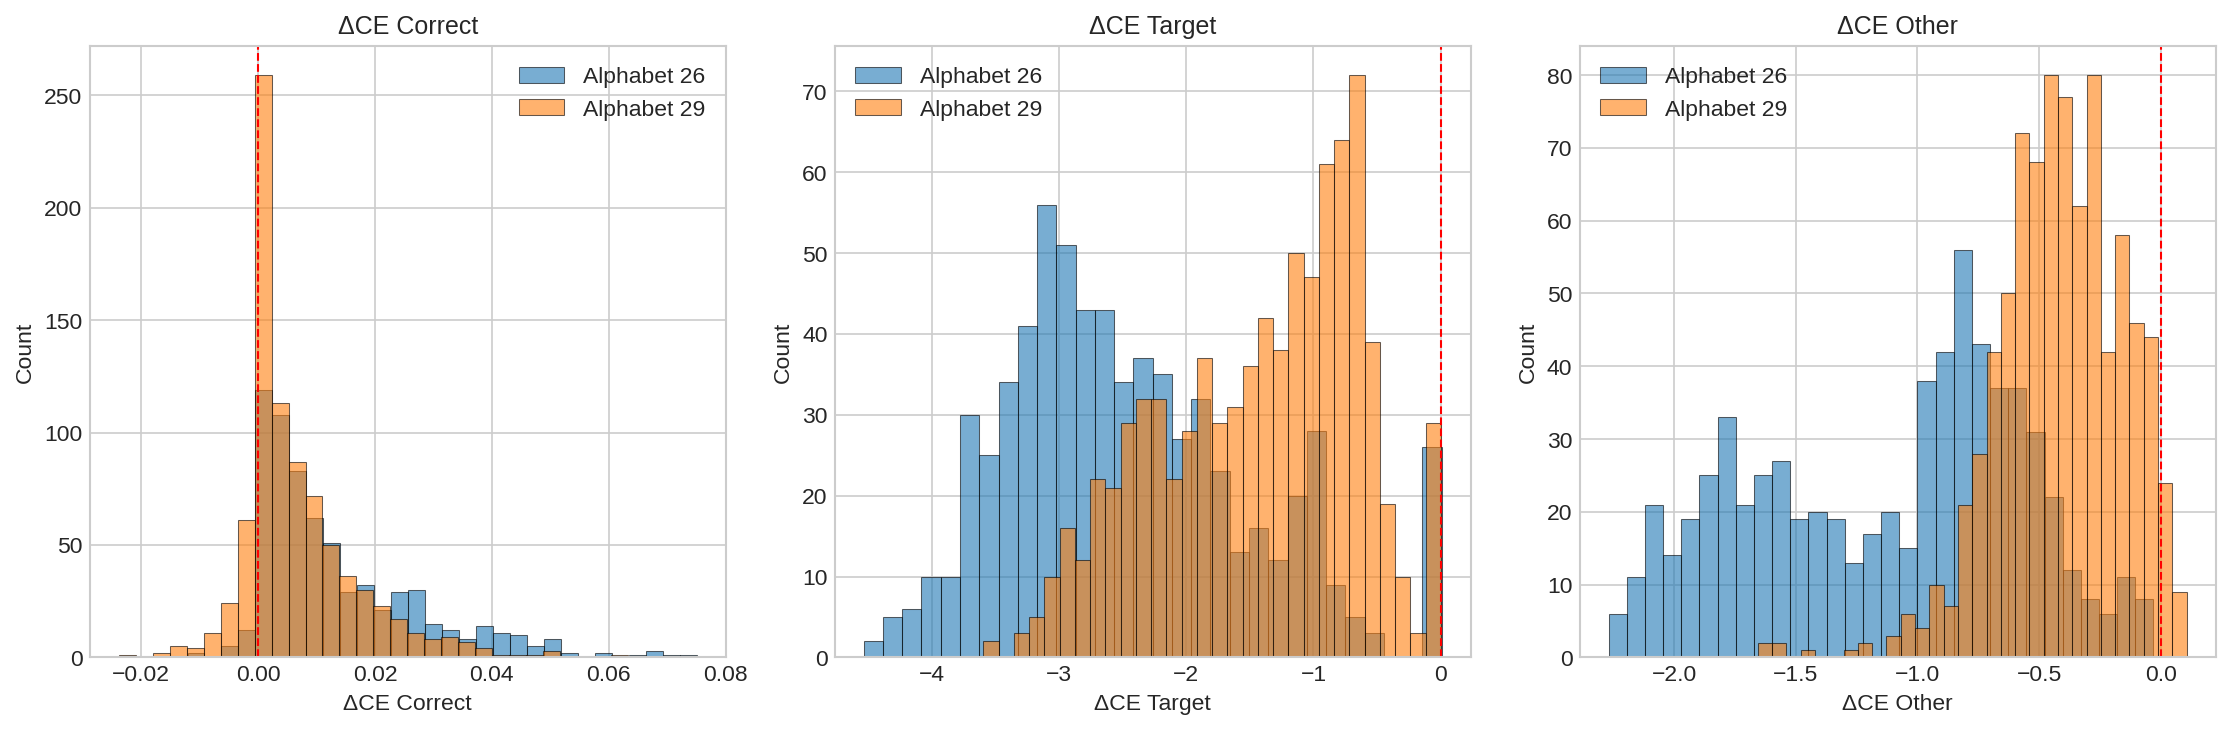

In [14]:
if len(df) > 0 and all(c in df.columns for c in ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other']):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other']
    titles = ['ΔCE Correct', 'ΔCE Target', 'ΔCE Other']
    
    for ax, metric, title in zip(axes, metrics, titles):
        for alph_size, color in [(26, 'C0'), (29, 'C1')]:
            df_alph = df[df['alphabet_size'] == alph_size]
            if len(df_alph) > 0:
                ax.hist(df_alph[metric], bins=30, alpha=0.6, 
                       label=f'Alphabet {alph_size}', color=color, edgecolor='black', linewidth=0.5)
        
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel(title)
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()
    
    plt.tight_layout()
    plt.savefig('figures/ce_changes.png', bbox_inches='tight')
    plt.show()

## 10. Paper-Ready Summary Figure

/local/user/1483801484/ipykernel_214753/564932855.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(data_to_plot, labels=labels, patch_artist=True)


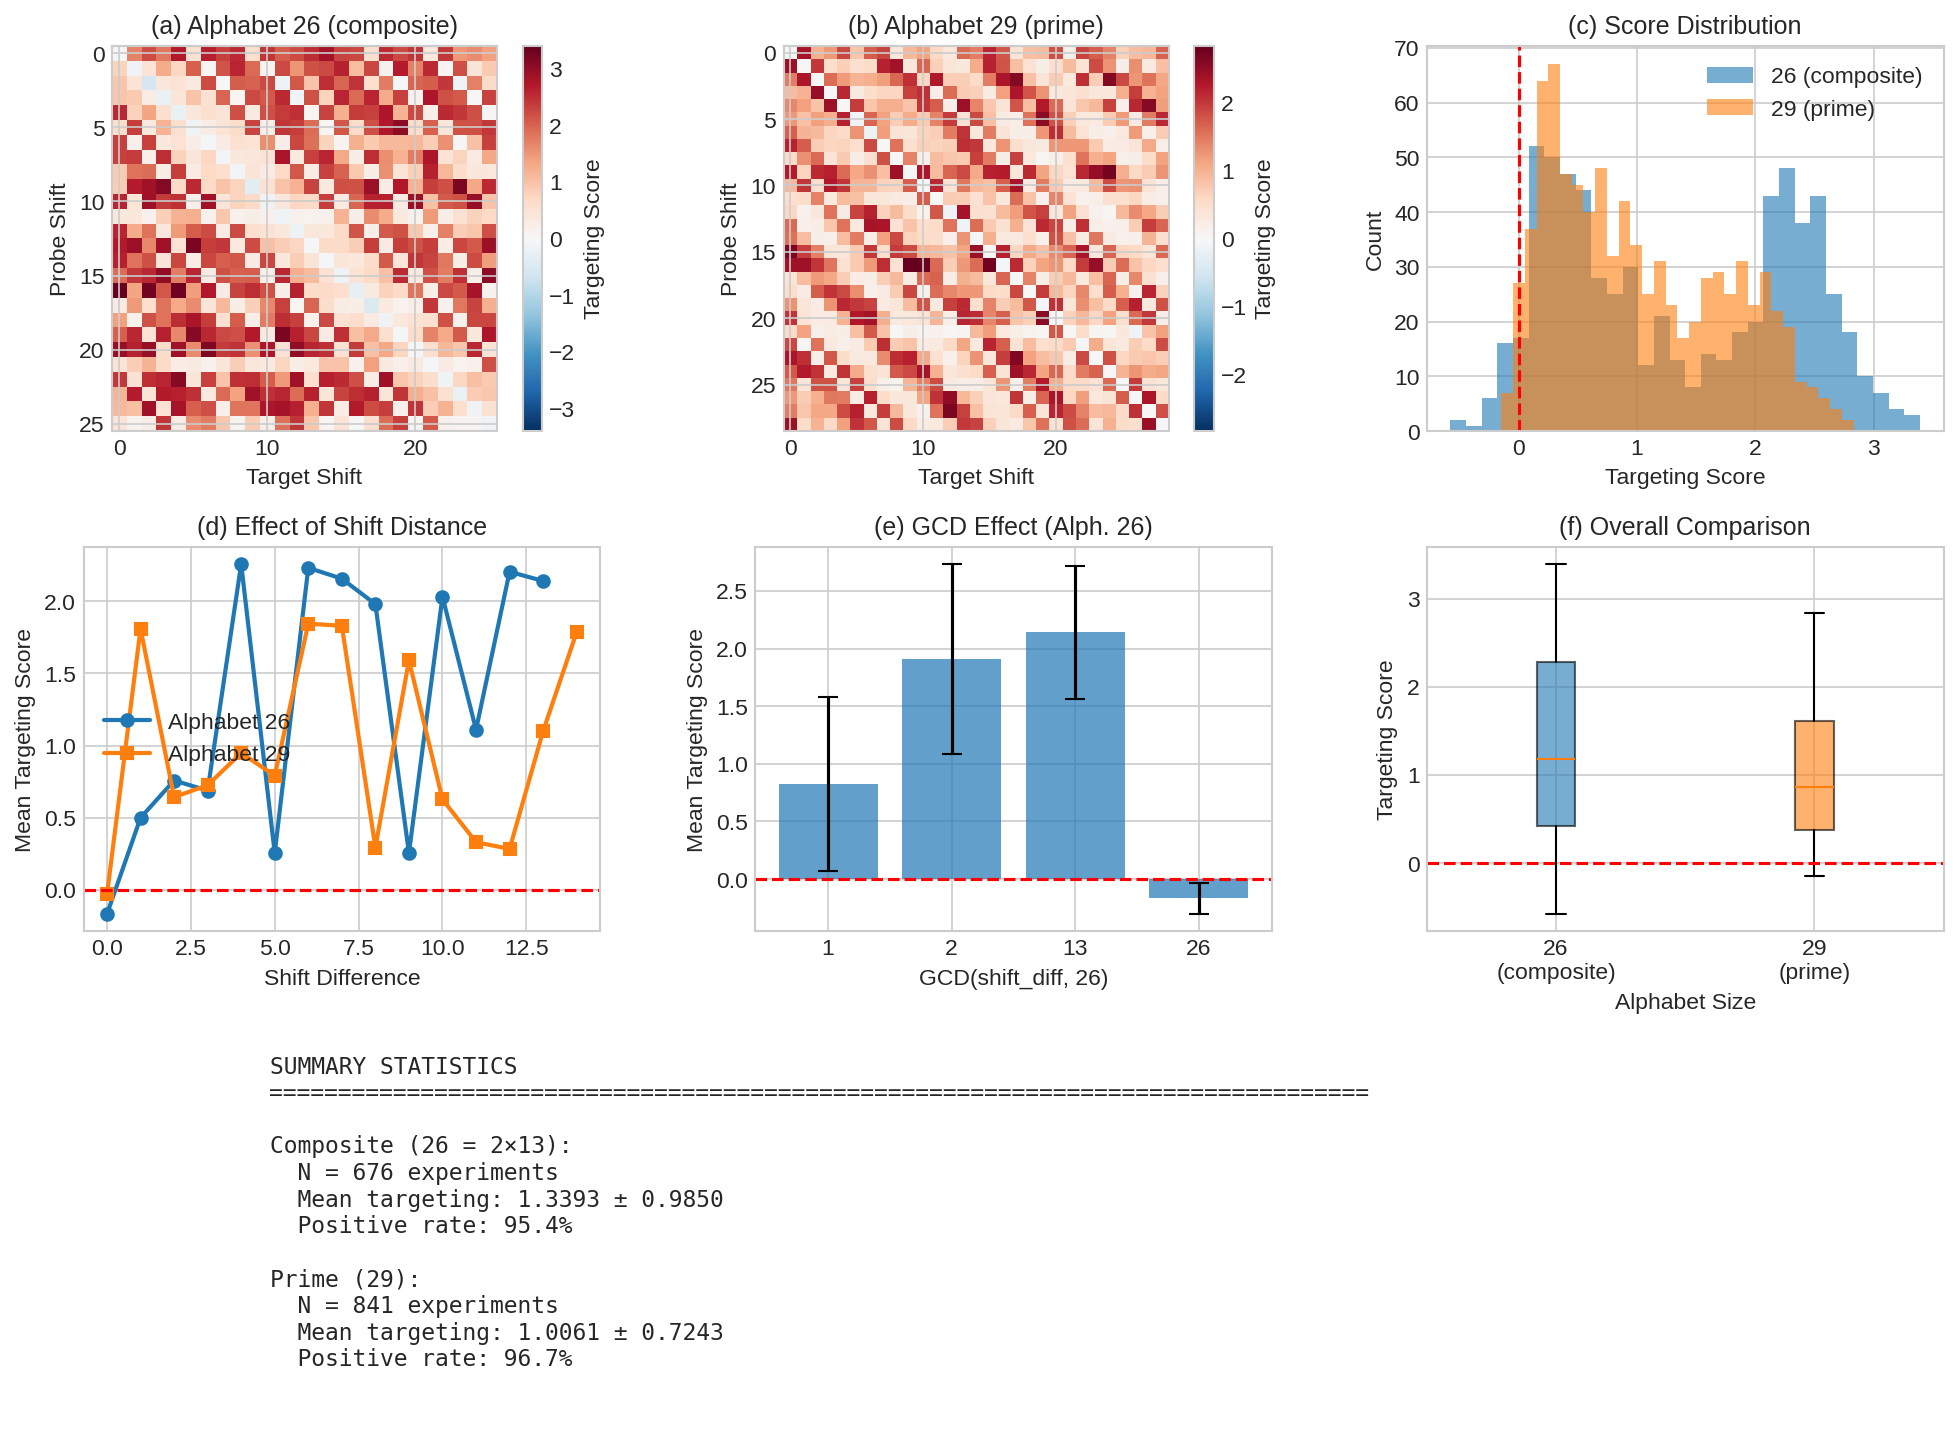


Figure saved to figures/paper_summary.png and figures/paper_summary.pdf


In [15]:
if len(df) > 0 and 'targeting_score' in df.columns:
    fig = plt.figure(figsize=(16, 12))
    
    # Create grid
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # (a) Targeting heatmap - Alphabet 26
    ax1 = fig.add_subplot(gs[0, 0])
    df_26 = df[df['alphabet_size'] == 26]
    if len(df_26) > 0:
        heatmap = np.full((26, 26), np.nan)
        for _, row in df_26.iterrows():
            heatmap[int(row['probe_shift']), int(row['target_shift'])] = row['targeting_score']
        vabs = max(abs(np.nanmin(heatmap)), abs(np.nanmax(heatmap)))
        im = ax1.imshow(heatmap, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
        ax1.set_xlabel('Target Shift')
        ax1.set_ylabel('Probe Shift')
        ax1.set_title('(a) Alphabet 26 (composite)')
        plt.colorbar(im, ax=ax1, label='Targeting Score')
    
    # (b) Targeting heatmap - Alphabet 29
    ax2 = fig.add_subplot(gs[0, 1])
    df_29 = df[df['alphabet_size'] == 29]
    if len(df_29) > 0:
        heatmap = np.full((29, 29), np.nan)
        for _, row in df_29.iterrows():
            heatmap[int(row['probe_shift']), int(row['target_shift'])] = row['targeting_score']
        vabs = max(abs(np.nanmin(heatmap)), abs(np.nanmax(heatmap)))
        im = ax2.imshow(heatmap, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
        ax2.set_xlabel('Target Shift')
        ax2.set_ylabel('Probe Shift')
        ax2.set_title('(b) Alphabet 29 (prime)')
        plt.colorbar(im, ax=ax2, label='Targeting Score')
    
    # (c) Distribution comparison
    ax3 = fig.add_subplot(gs[0, 2])
    if len(df_26) > 0:
        ax3.hist(df_26['targeting_score'], bins=30, alpha=0.6, label='26 (composite)', color='C0')
    if len(df_29) > 0:
        ax3.hist(df_29['targeting_score'], bins=30, alpha=0.6, label='29 (prime)', color='C1')
    ax3.axvline(0, color='red', linestyle='--')
    ax3.set_xlabel('Targeting Score')
    ax3.set_ylabel('Count')
    ax3.set_title('(c) Score Distribution')
    ax3.legend()
    
    # (d) Shift difference effect
    ax4 = fig.add_subplot(gs[1, 0])
    for alph_size, color, marker in [(26, 'C0', 'o'), (29, 'C1', 's')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            means = df_alph.groupby('shift_diff_wrapped')['targeting_score'].mean()
            ax4.plot(means.index, means.values, marker=marker, color=color, 
                    label=f'Alphabet {alph_size}', linewidth=2, markersize=6)
    ax4.axhline(0, color='red', linestyle='--')
    ax4.set_xlabel('Shift Difference')
    ax4.set_ylabel('Mean Targeting Score')
    ax4.set_title('(d) Effect of Shift Distance')
    ax4.legend()
    
    # (e) GCD effect for alphabet 26
    ax5 = fig.add_subplot(gs[1, 1])
    if len(df_26) > 0 and 'gcd_with_alph' in df_26.columns:
        gcd_means = df_26.groupby('gcd_with_alph')['targeting_score'].mean()
        gcd_stds = df_26.groupby('gcd_with_alph')['targeting_score'].std()
        ax5.bar(gcd_means.index.astype(str), gcd_means.values, yerr=gcd_stds.values,
               capsize=5, color='C0', alpha=0.7)
        ax5.axhline(0, color='red', linestyle='--')
        ax5.set_xlabel('GCD(shift_diff, 26)')
        ax5.set_ylabel('Mean Targeting Score')
        ax5.set_title('(e) GCD Effect (Alph. 26)')
    
    # (f) Box plot comparison
    ax6 = fig.add_subplot(gs[1, 2])
    data_to_plot = []
    labels = []
    if len(df_26) > 0:
        data_to_plot.append(df_26['targeting_score'].values)
        labels.append('26\n(composite)')
    if len(df_29) > 0:
        data_to_plot.append(df_29['targeting_score'].values)
        labels.append('29\n(prime)')
    if data_to_plot:
        bp = ax6.boxplot(data_to_plot, labels=labels, patch_artist=True)
        colors = ['C0', 'C1'][:len(data_to_plot)]
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
    ax6.axhline(0, color='red', linestyle='--')
    ax6.set_xlabel('Alphabet Size')
    ax6.set_ylabel('Targeting Score')
    ax6.set_title('(f) Overall Comparison')
    
    # (g-i) Summary statistics
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')
    
    # Create summary table
    summary_text = "SUMMARY STATISTICS\n" + "="*80 + "\n\n"
    
    for alph_size, name in [(26, 'Composite (26 = 2×13)'), (29, 'Prime (29)')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            summary_text += f"{name}:\n"
            summary_text += f"  N = {len(df_alph)} experiments\n"
            summary_text += f"  Mean targeting: {df_alph['targeting_score'].mean():.4f} ± {df_alph['targeting_score'].std():.4f}\n"
            summary_text += f"  Positive rate: {100*(df_alph['targeting_score'] > 0).mean():.1f}%\n\n"
    
    ax7.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
            verticalalignment='center', transform=ax7.transAxes)
    
    plt.savefig('figures/paper_summary.png', bbox_inches='tight', dpi=300)
    plt.savefig('figures/paper_summary.pdf', bbox_inches='tight')
    plt.show()
    
    print("\nFigure saved to figures/paper_summary.png and figures/paper_summary.pdf")
else:
    print("Insufficient data for summary figure.")

## 11. Export Results

In [16]:
# Create figures directory
import os
os.makedirs('figures', exist_ok=True)

# Save DataFrame
if len(df) > 0:
    df.to_csv('caesar_prime_comparison_results.csv', index=False)
    print(f"Saved {len(df)} experiments to caesar_prime_comparison_results.csv")
    
    # Also save summary statistics
    summary = df.groupby('alphabet_size')['targeting_score'].agg(['count', 'mean', 'std', 'min', 'max'])
    summary.to_csv('caesar_prime_comparison_summary.csv')
    print("\nSummary:")
    print(summary)

Saved 1517 experiments to caesar_prime_comparison_results.csv

Summary:
               count      mean       std       min       max
alphabet_size                                               
26               676  1.339255  0.985008 -0.578502  3.392593
29               841  1.006093  0.724276 -0.147776  2.831432


## 12. Final Paper Summary

In [17]:
if len(df) > 0 and 'targeting_score' in df.columns:
    print("\n" + "="*70)
    print("PAPER SUMMARY: PRIME VS COMPOSITE ALPHABET COMPARISON")
    print("="*70)
    
    print("\n1. EXPERIMENT SETUP")
    print(f"   - Alphabet 26 (a-z): {len(df[df['alphabet_size']==26])} / 676 experiments")
    print(f"   - Alphabet 29 (a-z+!?£): {len(df[df['alphabet_size']==29])} / 841 experiments")
    print(f"   - Total: {len(df)} experiments")
    print(f"   - Hyperparameters: ε=20, α=0.1, top_k=100 (negative mode), n_steps=30")
    
    print("\n2. MAIN RESULTS")
    for alph, name in [(26, 'Composite'), (29, 'Prime')]:
        df_alph = df[df['alphabet_size'] == alph]
        if len(df_alph) > 0:
            print(f"\n   {name} (n={alph}):")
            print(f"     Mean targeting: {df_alph['targeting_score'].mean():.4f}")
            print(f"     Std:            {df_alph['targeting_score'].std():.4f}")
            print(f"     Success rate:   {100*(df_alph['targeting_score'] > 0).mean():.1f}%")
    
    print("\n3. KEY FINDINGS")
    df_26 = df[df['alphabet_size'] == 26]['targeting_score']
    df_29 = df[df['alphabet_size'] == 29]['targeting_score']
    if len(df_26) > 0 and len(df_29) > 0:
        diff = df_29.mean() - df_26.mean()
        _, p_val = stats.ttest_ind(df_26, df_29)
        print(f"   - Difference (29 - 26): {diff:+.4f}")
        print(f"   - Statistical significance: p = {p_val:.4e}")
        if p_val < 0.05:
            if diff > 0:
                print("   - CONCLUSION: Prime alphabet shows BETTER targeting")
            else:
                print("   - CONCLUSION: Composite alphabet shows BETTER targeting")
        else:
            print("   - CONCLUSION: No significant difference between alphabets")
    
    print("\n" + "="*70)


PAPER SUMMARY: PRIME VS COMPOSITE ALPHABET COMPARISON

1. EXPERIMENT SETUP
   - Alphabet 26 (a-z): 676 / 676 experiments
   - Alphabet 29 (a-z+!?£): 841 / 841 experiments
   - Total: 1517 experiments
   - Hyperparameters: ε=20, α=0.1, top_k=100 (negative mode), n_steps=30

2. MAIN RESULTS

   Composite (n=26):
     Mean targeting: 1.3393
     Std:            0.9850
     Success rate:   95.4%

   Prime (n=29):
     Mean targeting: 1.0061
     Std:            0.7243
     Success rate:   96.7%

3. KEY FINDINGS
   - Difference (29 - 26): -0.3332
   - Statistical significance: p = 5.7940e-14
   - CONCLUSION: Composite alphabet shows BETTER targeting

